<a href="https://colab.research.google.com/github/KuberChhabra1105/NeuroRec-Hebbian-Memory/blob/main/KDSH_DataDonz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers umap-learn matplotlib seaborn \
scikit-learn wordcloud tqdm --quiet


In [ ]:
import os

BASE_DIR = "/content/writingprompts"
print("Files found:")
for f in os.listdir(BASE_DIR):
    print(" -", f)


Files found:
 - train.wp_source
 - README
 - test.wp_source
 - valid.wp_target
 - test.wp_target
 - train.wp_target
 - valid.wp_source


In [ ]:
def read_wp_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read().splitlines()


In [ ]:
train_prompts = read_wp_file(f"{BASE_DIR}/train.wp_source")
train_stories = read_wp_file(f"{BASE_DIR}/train.wp_target")

valid_prompts = read_wp_file(f"{BASE_DIR}/valid.wp_source")
valid_stories = read_wp_file(f"{BASE_DIR}/valid.wp_target")

test_prompts  = read_wp_file(f"{BASE_DIR}/test.wp_source")
test_stories  = read_wp_file(f"{BASE_DIR}/test.wp_target")

print("Raw counts")
print("Train:", len(train_prompts), len(train_stories))
print("Valid:", len(valid_prompts), len(valid_stories))
print("Test :", len(test_prompts), len(test_stories))


Raw counts
Train: 164073 6340
Valid: 15620 6566
Test : 15138 6336


In [ ]:
def clean_lines(lines):
    return [l.strip() for l in lines if l.strip() != ""]


In [ ]:
import pandas as pd

def build_df(prompts, stories):
    p = clean_lines(prompts)
    s = clean_lines(stories)
    n = min(len(p), len(s))
    return pd.DataFrame({
        "prompt": p[:n],
        "story": s[:n]
    })

train_df = build_df(train_prompts, train_stories)
valid_df = build_df(valid_prompts, valid_stories)
test_df  = build_df(test_prompts, test_stories)

print("Final samples")
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))


Final samples
Train: 6340
Valid: 6566
Test : 6336


In [ ]:
for df in [train_df, valid_df, test_df]:
    df["prompt_len"] = df["prompt"].apply(lambda x: len(x.split()))
    df["story_len"]  = df["story"].apply(lambda x: len(x.split()))

train_df.head()


,prompt,story,prompt_len,story_len
0,[ WP ] You 've finally managed to discover the...,"So many times have I walked on ruins , the rem...",52,661
1,"[ WP ] The moon is actually a giant egg , and ...","-Week 18 aboard the Depth Reaver , Circa 2023-...",19,690
2,[ WP ] You find a rip in time walking through ...,"I was feckin ' sloshed , mate . First time I e...",34,568
3,[ WP ] For years in your youth the same imagin...,"“ No , no no no ... ” She backed up and turned...",50,661
4,"[ WP ] You glance at your watch 10:34 am , rou...",There 's a magical moment between wakefulness ...,46,1084


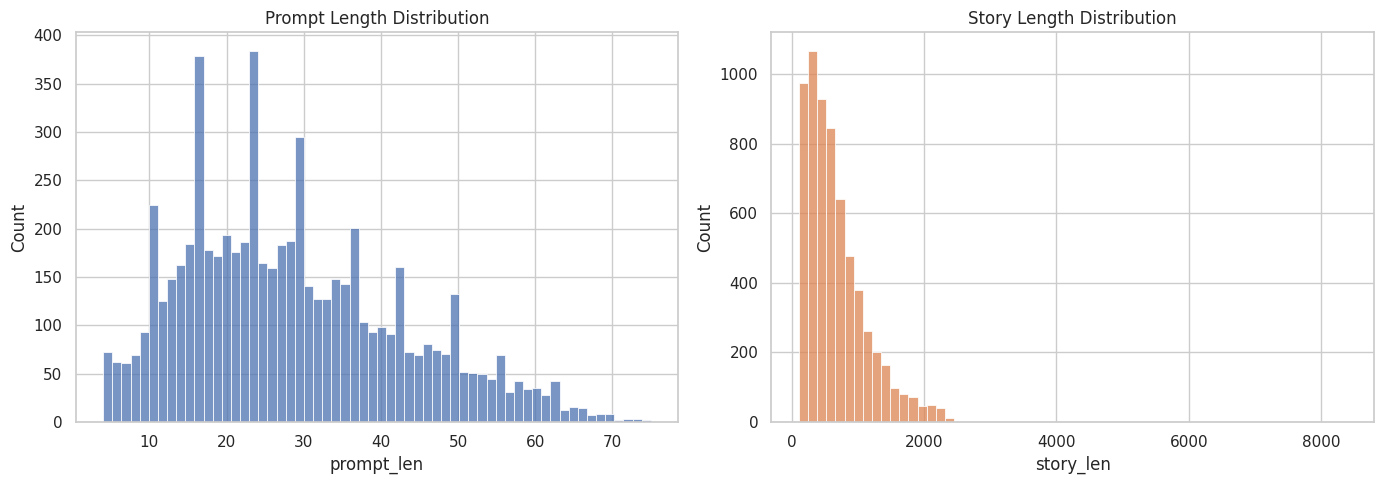

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(train_df["prompt_len"], bins=60, color="#4C72B0")
plt.title("Prompt Length Distribution")

plt.subplot(1,2,2)
sns.histplot(train_df["story_len"], bins=60, color="#DD8452")
plt.title("Story Length Distribution")

plt.tight_layout()
plt.show()


/tmp/ipython-input-282360035.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(c), y=list(w), palette="viridis")


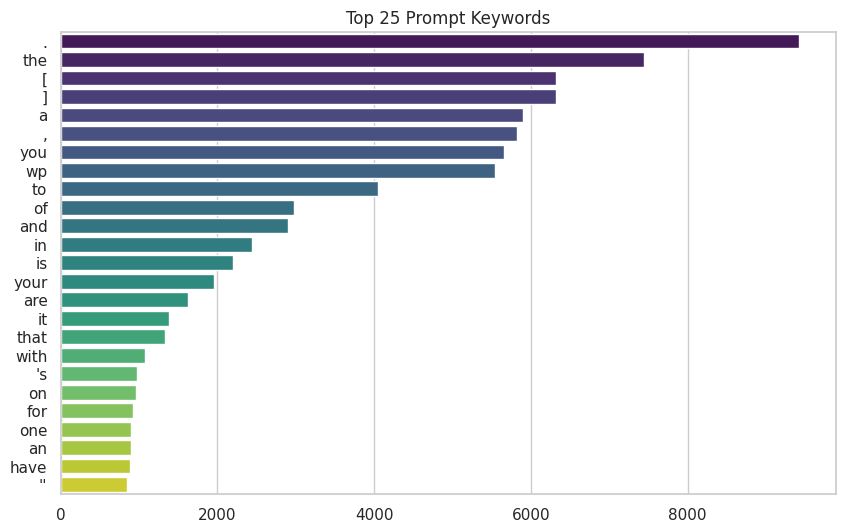

In [ ]:
from collections import Counter

words = " ".join(train_df["prompt"]).lower().split()
top_words = Counter(words).most_common(25)

w, c = zip(*top_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(c), y=list(w), palette="viridis")
plt.title("Top 25 Prompt Keywords")
plt.show()


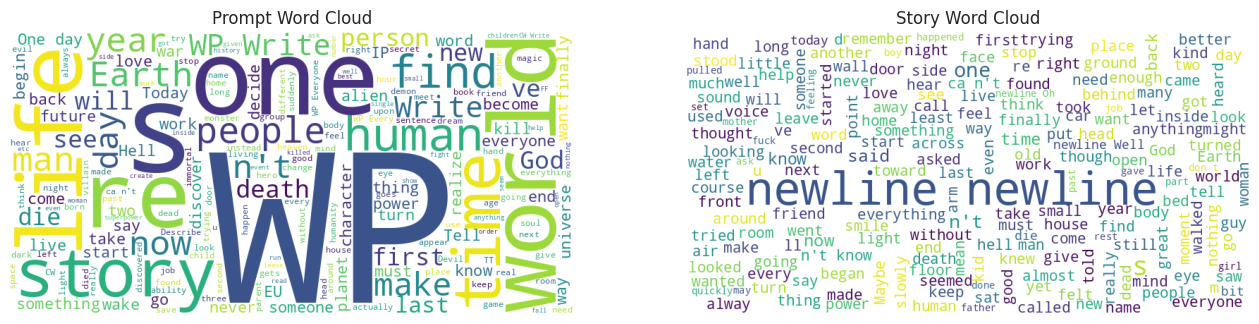

In [ ]:
from wordcloud import WordCloud

prompt_wc = WordCloud(width=800, height=400, background_color="white") \
            .generate(" ".join(train_df["prompt"]))

story_wc = WordCloud(width=800, height=400, background_color="white") \
           .generate(" ".join(train_df["story"]))

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.imshow(prompt_wc)
plt.axis("off")
plt.title("Prompt Word Cloud")

plt.subplot(1,2,2)
plt.imshow(story_wc)
plt.axis("off")
plt.title("Story Word Cloud")

plt.show()


Correlation: 0.112


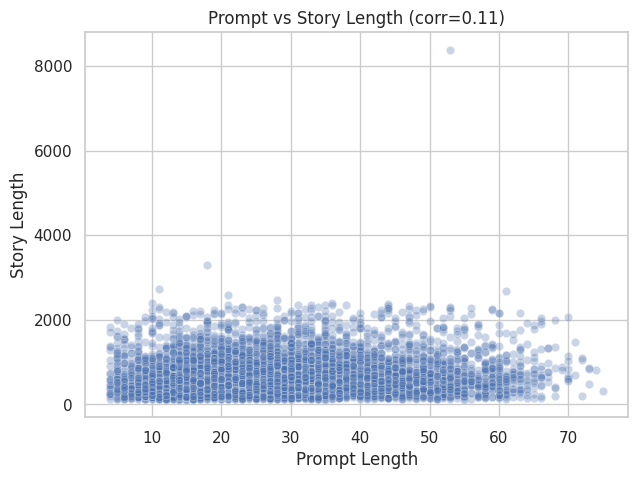

In [ ]:
corr = train_df["prompt_len"].corr(train_df["story_len"])
print("Correlation:", round(corr, 3))

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=train_df["prompt_len"],
    y=train_df["story_len"],
    alpha=0.3
)
plt.title(f"Prompt vs Story Length (corr={corr:.2f})")
plt.xlabel("Prompt Length")
plt.ylabel("Story Length")
plt.show()


In [ ]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

sample_df = train_df.sample(3000, random_state=42)

prompt_emb = embedder.encode(
    sample_df["prompt"].tolist(),
    show_progress_bar=True
)

story_emb = embedder.encode(
    sample_df["story"].tolist(),
    show_progress_bar=True
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sample_df["semantic_similarity"] = [
    cosine_similarity([p], [s])[0][0]
    for p, s in zip(prompt_emb, story_emb)
]


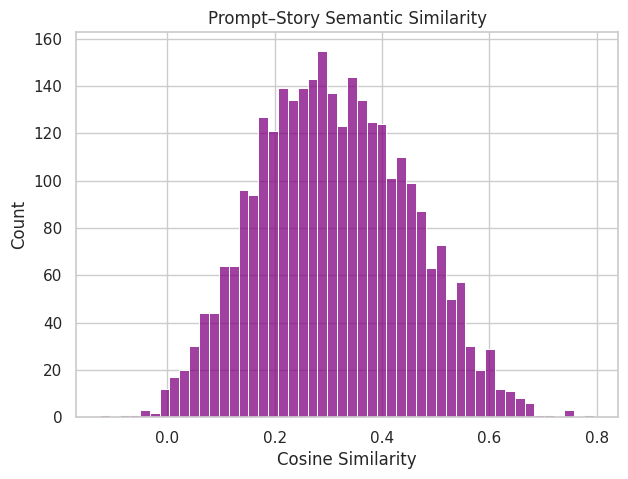

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(sample_df["semantic_similarity"], bins=50, color="purple")
plt.title("Prompt–Story Semantic Similarity")
plt.xlabel("Cosine Similarity")
plt.show()


/tmp/ipython-input-3235957321.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


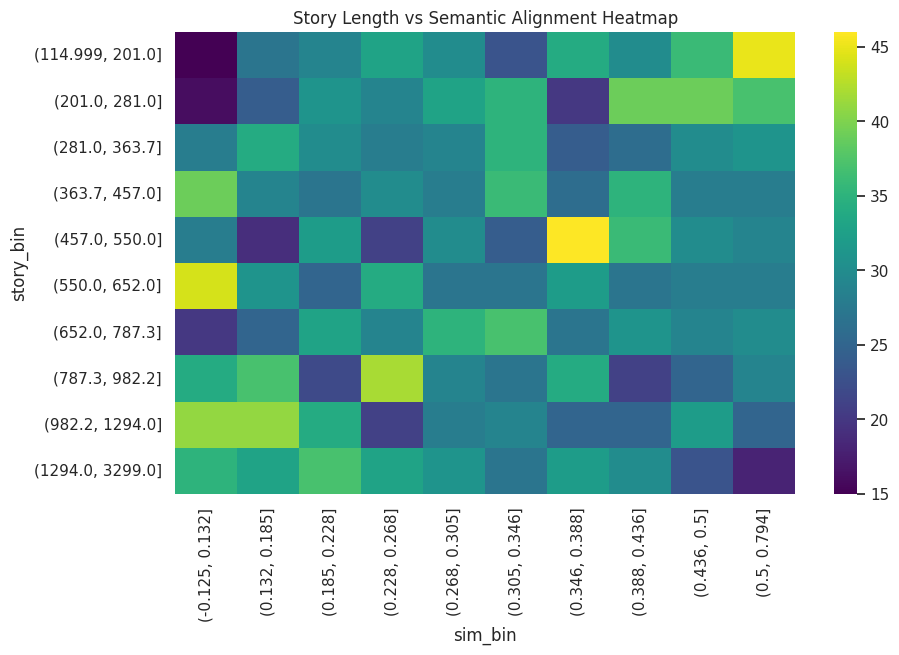

In [ ]:
sample_df["story_bin"] = pd.qcut(sample_df["story_len"], 10)
sample_df["sim_bin"]   = pd.qcut(sample_df["semantic_similarity"], 10)

pivot = pd.pivot_table(
    sample_df,
    values="prompt_len",
    index="story_bin",
    columns="sim_bin",
    aggfunc="count"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Story Length vs Semantic Alignment Heatmap")
plt.show()


In [ ]:
import random

def corrupt_prompt(prompt):
    tokens = prompt.split()
    if len(tokens) > 5:
        idx = random.randint(0, len(tokens)-1)
        tokens[idx] = "NOT_" + tokens[idx]
    return " ".join(tokens)

sample_df["corrupt_prompt"] = sample_df["prompt"].apply(corrupt_prompt)


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

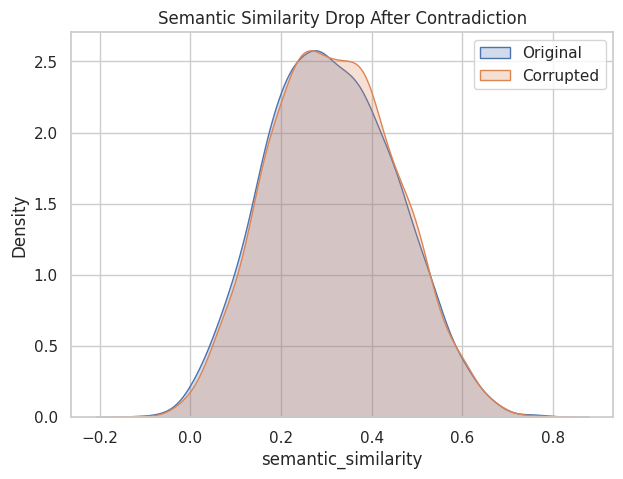

In [ ]:
corrupt_emb = embedder.encode(
    sample_df["corrupt_prompt"].tolist(),
    show_progress_bar=True
)

corrupt_sim = [
    cosine_similarity([p], [s])[0][0]
    for p, s in zip(corrupt_emb, story_emb)
]

plt.figure(figsize=(7,5))
sns.kdeplot(sample_df["semantic_similarity"], label="Original", fill=True)
sns.kdeplot(corrupt_sim, label="Corrupted", fill=True)
plt.title("Semantic Similarity Drop After Contradiction")
plt.legend()
plt.show()


In [ ]:
def chunk_text(text, chunk_size=100):
    words = text.split()
    return [
        " ".join(words[i:i+chunk_size])
        for i in range(0, len(words), chunk_size)
    ]

example_story = train_df.iloc[0]["story"]
chunks = chunk_text(example_story)

chunk_embs = embedder.encode(chunks, show_progress_bar=True)

memory_states = []
state = chunk_embs[0]

for emb in chunk_embs[1:]:
    state = 0.8 * state + 0.2 * emb
    memory_states.append(state)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

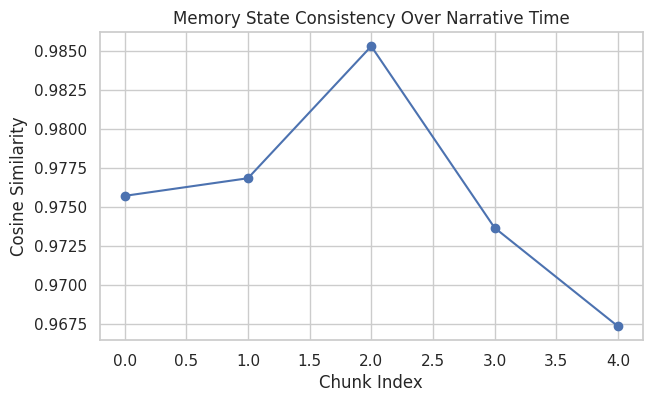

In [ ]:
drift = [
    cosine_similarity([memory_states[i]], [memory_states[i+1]])[0][0]
    for i in range(len(memory_states)-1)
]

plt.figure(figsize=(7,4))
plt.plot(drift, marker="o")
plt.title("Memory State Consistency Over Narrative Time")
plt.xlabel("Chunk Index")
plt.ylabel("Cosine Similarity")
plt.show()


In [ ]:
print("DATASET SUMMARY")
print("----------------")
print("Train samples:", len(train_df))
print("Avg prompt length:", int(train_df["prompt_len"].mean()))
print("Avg story length :", int(train_df["story_len"].mean()))
print("Avg semantic similarity:",
      round(sample_df["semantic_similarity"].mean(), 3))


DATASET SUMMARY
----------------
Train samples: 6340
Avg prompt length: 28
Avg story length : 668
Avg semantic similarity: 0.311


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np


In [ ]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")


In [ ]:
def chunk_text(text, chunk_size=120):
    words = text.split()
    return [
        " ".join(words[i:i+chunk_size])
        for i in range(0, len(words), chunk_size)
    ]


In [ ]:
def build_story_memory(story, alpha=0.8):
    chunks = chunk_text(story)
    if len(chunks) == 0:
        return None

    chunk_embs = embedder.encode(chunks)

    memory = chunk_embs[0]
    for emb in chunk_embs[1:]:
        memory = alpha * memory + (1 - alpha) * emb

    return memory


In [ ]:
def consistency_score(prompt, story):
    prompt_emb = embedder.encode([prompt])[0]
    memory_emb = build_story_memory(story)

    if memory_emb is None:
        return 0.0

    score = cosine_similarity(
        [prompt_emb],
        [memory_emb]
    )[0][0]

    return score


In [ ]:

val_scores = []

for _, row in valid_df.sample(500, random_state=42).iterrows():
    s = consistency_score(row["prompt"], row["story"])
    val_scores.append(s)

threshold = np.mean(val_scores)
threshold


np.float32(0.35561797)

In [ ]:
def predict_label(prompt, story, threshold):
    score = consistency_score(prompt, story)
    return int(score >= threshold)


In [ ]:
test_prompts = test_df["prompt"].tolist()
prompt_embeddings = embedder.encode(
    test_prompts,
    show_progress_bar=True,
    batch_size=32
)


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def build_story_memory_fast(stories, alpha=0.8, chunk_size=120):
    all_chunks = []
    chunk_map = []  # story index mapping

    for i, story in enumerate(stories):
        words = story.split()
        chunks = [
            " ".join(words[j:j+chunk_size])
            for j in range(0, len(words), chunk_size)
        ]
        all_chunks.extend(chunks)
        chunk_map.extend([i] * len(chunks))

    # 🔥 ONE embedding call (THIS is the speedup)
    chunk_embeddings = embedder.encode(
        all_chunks,
        batch_size=64,
        show_progress_bar=True
    )

    # build memory per story
    memories = [None] * len(stories)
    counts = [0] * len(stories)

    for emb, idx in zip(chunk_embeddings, chunk_map):
        if memories[idx] is None:
            memories[idx] = emb
        else:
            memories[idx] = alpha * memories[idx] + (1 - alpha) * emb
        counts[idx] += 1

    return memories


In [ ]:
story_memories = build_story_memory_fast(
    test_df["story"].tolist()
)


Batches:   0%|          | 0/604 [00:00<?, ?it/s]

In [ ]:
prompt_embeddings = embedder.encode(
    test_df["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True
)


Batches:   0%|          | 0/99 [00:00<?, ?it/s]

In [ ]:
scores = cosine_similarity(
    np.array(prompt_embeddings),
    np.array(story_memories)
).diagonal()

predictions = (scores >= threshold).astype(int)


In [ ]:
results_df = pd.DataFrame({
    "id": test_df.index,
    "prediction": predictions
})

results_df.to_csv("results.csv", index=False)
results_df.head()


,id,prediction
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [ ]:
import os

os.listdir("/content")


['.config',
 '.ipynb_checkpoints',
 'writingprompts',
 'results.csv',
 'sample_data']